In [20]:
import pandas as pd
import pyreadstat

dm, meta = pyreadstat.read_sas7bdat("C:/Users/dharm/Clinical_Trial_SDTM_Project/raw_data/demog.sas7bdat")
ae, meta = pyreadstat.read_sas7bdat("C:/Users/dharm/Clinical_Trial_SDTM_Project/raw_data/ae.sas7bdat")
lab, meta = pyreadstat.read_sas7bdat("C:/Users/dharm/Clinical_Trial_SDTM_Project/raw_data/lb.sas7bdat")

In [21]:
dm.shape, ae.shape, lab.shape

((476, 13), (5880, 74), (6812, 25))

In [22]:
dm["SUBID"].nunique(), ae["SUBID"].nunique(), lab["SUBID"].nunique()

(476, 441, 470)

In [23]:
ae_summary = ae.groupby("SUBID").size().reset_index(name="AE_COUNT")
ae_summary.head()

,SUBID,AE_COUNT
0,001-0003,13
1,001-0004,6
2,001-0005,11
3,001-0008,4
4,001-0009,21


In [24]:
lab_summary = lab.groupby("SUBID").size().reset_index(name="LB_COUNT")
lab_summary.head()

,SUBID,LB_COUNT
0,001-0003,13
1,001-0004,13
2,001-0005,13
3,001-0008,13
4,001-0009,13


In [25]:
final = dm.merge(ae_summary, on="SUBID", how="left") \
          .merge(lab_summary, on="SUBID", how="left")

final.fillna(0, inplace=True)

final.head()

,PROJ_ID,SITE_ID,SUBID,STATE,EVENT_NO,EVENT_ID,ID,RACE,CNSNTDT_,RACEOTHE,SEX,BIRTHDT_,CNSNT,AE_COUNT,LB_COUNT
0,DN-101 Protocol No. 011-007,001,001-0003,5.0,0.0,Subject Demographics,2.603014e+09,1.0,0.0,,1.0,-26050.0,1.0,13.0,13.0
1,DN-101 Protocol No. 011-007,001,001-0004,5.0,1.0,Subject Demographics,2.642913e+09,0.0,0.0,,1.0,-28545.0,1.0,6.0,13.0
2,DN-101 Protocol No. 011-007,001,001-0005,5.0,1.0,Subject Demographics,2.683452e+09,0.0,0.0,,1.0,-26441.0,1.0,11.0,13.0
3,DN-101 Protocol No. 011-007,001,001-0008,5.0,1.0,Subject Demographics,2.746568e+09,0.0,0.0,,1.0,-27486.0,1.0,4.0,13.0
4,DN-101 Protocol No. 011-007,001,001-0009,5.0,1.0,Subject Demographics,2.752143e+09,0.0,0.0,,1.0,-25408.0,1.0,21.0,13.0


In [26]:
final_clean = final[[
    "SUBID",
    "SEX",
    "RACE",
    "AE_COUNT",
    "LB_COUNT"
]]

In [27]:
final_clean.fillna(0, inplace=True)
final_clean.head()

,SUBID,SEX,RACE,AE_COUNT,LB_COUNT
0,001-0003,1.0,1.0,13.0,13.0
1,001-0004,1.0,0.0,6.0,13.0
2,001-0005,1.0,0.0,11.0,13.0
3,001-0008,1.0,0.0,4.0,13.0
4,001-0009,1.0,0.0,21.0,13.0


In [28]:
final_clean["SEX_LABEL"] = final_clean["SEX"].map({
    1.0: "Male",
    2.0: "Female"
})

In [29]:
final_clean["RACE_LABEL"] = final_clean["RACE"].map({
    0.0: "White",
    1.0: "Black",
    2.0: "Hispanic or Latino",
    3.0: "Asian",
    4.0: "American Indian or Alaskan Native",
    5.0: "Native Hawaiian or Other Pacific Islander",
    99.0: "Other"
})

In [30]:
final_clean["RISK"] = "Low"

final_clean.loc[final_clean["AE_COUNT"] >= 10, "RISK"] = "High"

In [31]:
final_clean.head()

,SUBID,SEX,RACE,AE_COUNT,LB_COUNT,SEX_LABEL,RACE_LABEL,RISK
0,001-0003,1.0,1.0,13.0,13.0,Male,Black,High
1,001-0004,1.0,0.0,6.0,13.0,Male,White,Low
2,001-0005,1.0,0.0,11.0,13.0,Male,White,High
3,001-0008,1.0,0.0,4.0,13.0,Male,White,Low
4,001-0009,1.0,0.0,21.0,13.0,Male,White,High


In [32]:
ae_severity = ae.groupby("SUBID")["AETOXGR"].max().reset_index()
ae_severity.rename(columns={"AETOXGR": "MAX_AE_GRADE"}, inplace=True)

In [34]:
final_clean = final_clean.merge(ae_severity, on="SUBID", how="left")

In [35]:
final_clean["SEVERITY_LABEL"] = final_clean["MAX_AE_GRADE"].map({
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Life-threatening",
    5: "Death"
})

In [37]:
# Fill numeric columns only
num_cols = final_clean.select_dtypes(include=["number"]).columns
final_clean[num_cols] = final_clean[num_cols].fillna(0)

In [38]:
# Fill string columns separately
str_cols = final_clean.select_dtypes(include=["object"]).columns
final_clean[str_cols] = final_clean[str_cols].fillna("Unknown")

C:\Users\dharm\AppData\Local\Temp\ipykernel_18224\1909785582.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = final_clean.select_dtypes(include=["object"]).columns


In [39]:
final_clean.isnull().sum()

SUBID             0
SEX               0
RACE              0
AE_COUNT          0
LB_COUNT          0
SEX_LABEL         0
RACE_LABEL        0
RISK              0
MAX_AE_GRADE      0
SEVERITY_LABEL    0
dtype: int64

In [40]:
final_clean.to_csv("final_clinical_dataset.csv", index=False)

In [41]:
# Risk distribution

final_clean["RISK"].value_counts()

RISK
High    253
Low     223
Name: count, dtype: int64

In [42]:
# High AE patients

final_clean.sort_values("AE_COUNT", ascending=False).head(10)

,SUBID,SEX,RACE,AE_COUNT,LB_COUNT,SEX_LABEL,RACE_LABEL,RISK,MAX_AE_GRADE,SEVERITY_LABEL
371,506-0004,1.0,0.0,75.0,13.0,Male,White,High,2.0,Moderate
258,127-0010,1.0,0.0,66.0,13.0,Male,White,High,4.0,Life-threatening
253,127-0004,1.0,0.0,60.0,13.0,Male,White,High,4.0,Life-threatening
370,506-0003,1.0,0.0,57.0,0.0,Male,White,High,4.0,Life-threatening
121,061-0002,1.0,0.0,57.0,13.0,Male,White,High,4.0,Life-threatening
12,002-0016,1.0,0.0,51.0,13.0,Male,White,High,3.0,Severe
104,049-0003,1.0,0.0,50.0,13.0,Male,White,High,4.0,Life-threatening
185,098-0001,1.0,0.0,48.0,13.0,Male,White,High,3.0,Severe
123,061-0004,1.0,0.0,48.0,26.0,Male,White,High,4.0,Life-threatening
215,117-0001,1.0,0.0,47.0,13.0,Male,White,High,4.0,Life-threatening


In [43]:
# Lab burden comparison

final_clean.groupby("RISK")["LB_COUNT"].mean()

RISK
High    14.490119
Low     14.107623
Name: LB_COUNT, dtype: float64

<Axes: xlabel='RISK'>

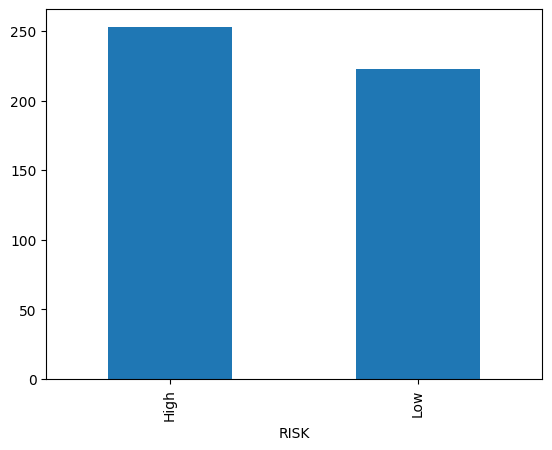

In [44]:
final_clean["RISK"].value_counts().plot(kind="bar")